In [1]:
# ===== Lesson 12 — Day 1: Normalization + HVG =====

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
!pip install scanpy -q
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/scRNA_project")
DATASETS = PROJECT / "datasets"

adata = sc.read_h5ad(str(DATASETS / "pbmc3k_filtered.h5ad"))
print("Loaded shape:", adata.shape)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible

In [2]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)

normalized_totals = np.asarray(adata.X.sum(axis=1)).flatten()
print("First 10 normalized totals:", normalized_totals[:10])
print("Mean normalized total:", normalized_totals.mean())

sc.pp.log1p(adata)

First 10 normalized totals: [10000.    10000.    10000.     9999.998 10000.001 10000.    10000.
 10000.    10000.001 10000.   ]
Mean normalized total: 10000.0


highly_variable
False    11714
True      2000
Name: count, dtype: int64
Number of HVGs: 2000
First 20 HVGs: ['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1', 'TNFRSF25', 'TNFRSF9', 'CA6', 'CTNNBIP1', 'SRM', 'UBIAD1', 'DRAXIN', 'NPPA-AS1', 'TNFRSF1B', 'PRDM2', 'EFHD2', 'DDI2', 'SPEN', 'SDHB', 'CAPZB']


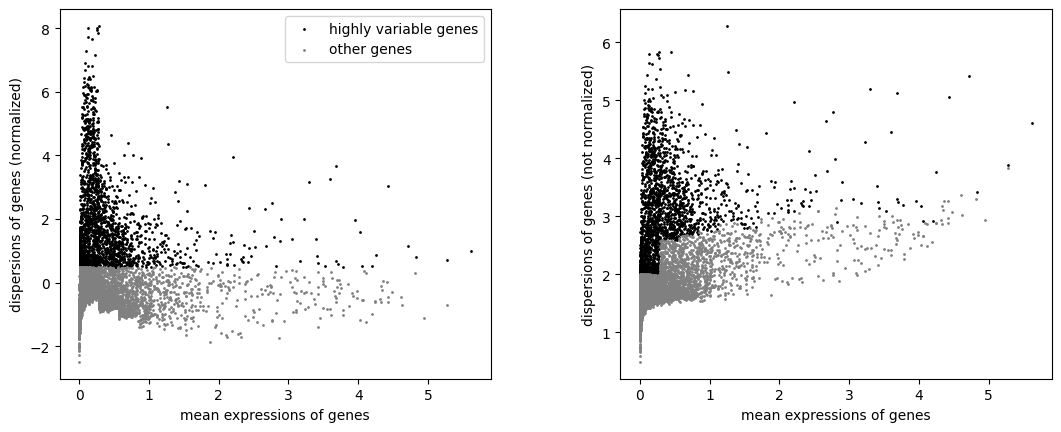

In [3]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")

print(adata.var["highly_variable"].value_counts())

hvg_genes = adata.var_names[adata.var["highly_variable"]]
print("Number of HVGs:", len(hvg_genes))
print("First 20 HVGs:", list(hvg_genes[:20]))

sc.pl.highly_variable_genes(adata, show=True)

In [4]:
normalized_hvg_file = DATASETS / "pbmc3k_normalized_hvg.h5ad"
adata.write(str(normalized_hvg_file))
print("Saved:", normalized_hvg_file)

Saved: /content/drive/MyDrive/scRNA_project/datasets/pbmc3k_normalized_hvg.h5ad


In [5]:
!git add .
!git commit -m "Feat(Lesson12): Normalization and HVG selection applied to PBMC3k"

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [6]:
%cd /content/drive/MyDrive/scRNA_project
!pwd

/content/drive/MyDrive/scRNA_project
/content/drive/MyDrive/scRNA_project


In [7]:
!git add .
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/Lesson11_Git_and_GitHub.ipynb
	new file:   notebooks/Lesson12_Normalization_and_HVG.ipynb



In [8]:
!git commit -m "Feat(Lesson12): Normalization and HVG selection applied to PBMC3k"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@9015caee0e86.(none)')


In [9]:
!git config --global user.name "caseypyth"
!git config --global user.email "caseypyth@gmail.com"

In [10]:
!git commit -m "Feat(Lesson12): Normalization and HVG selection applied to PBMC3k"

[main e4e72fe] Feat(Lesson12): Normalization and HVG selection applied to PBMC3k
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 notebooks/Lesson12_Normalization_and_HVG.ipynb
